In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\nagy\OneDrive\Desktop\Portfolio\Superstore_Dataset\Superstore.csv', encoding='latin-1')
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nFirst 3 rows:\n{df.head(3)}")

Shape: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment   

In [9]:
import pandas as pd
df = pd.read_csv(r'C:\Users\nagy\OneDrive\Desktop\Portfolio\Superstore_Dataset\Superstore.csv', encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.strftime('%Y-%m')
df['Profit Margin'] = (df['Profit'] / df['Sales'] * 100).round(2)
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print("✅ Columns added successfully")
print(f"\nYears in dataset: {sorted(df['Year'].unique())}")
print(f"Regions: {df['Region'].unique()}")
print(f"Categories: {df['Category'].unique()}")

print("\n" + "="*45)
print("FINANCIAL SUMMARY:")
print("="*45)
print(f"Total Sales:          ${df['Sales'].sum():>12,.0f}")
print(f"Total Profit:         ${df['Profit'].sum():>12,.0f}")
print(f"Avg Profit Margin:    {df['Profit Margin'].mean():>11.1f}%")
print(f"Total Orders:         {df['Order ID'].nunique():>12,}")
print(f"Avg Discount:         {df['Discount'].mean()*100:>11.1f}%")
print(f"Avg Shipping Days:    {df['Shipping Days'].mean():>11.1f} days")

cat_analysis = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Profit Margin', 'mean'),
    Orders=('Order ID', 'count')
).round(2).sort_values('Total_Profit', ascending=False)

print("\n--- Profit by Category ---")
print(cat_analysis.to_string())

region_analysis = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Profit Margin', 'mean')
).round(2).sort_values('Total_Profit', ascending=False)

print("\n--- Profit by Region ---")
print(region_analysis.to_string())

df['Discount Band'] = pd.cut(df['Discount'],
    bins=[-0.1, 0, 0.2, 0.4, 1.0],
    labels=['No Discount', 'Low (1-20%)', 'Medium (21-40%)', 'High (41%+)'])

discount_impact = df.groupby('Discount Band', observed=True).agg(
    Avg_Profit=('Profit', 'mean'),
    Total_Orders=('Order ID', 'count')
).round(2)

print("\n--- Discount Impact on Profit ---")
print(discount_impact.to_string())

df.to_csv('superstore_clean.csv', index=False)
print("\n✅ superstore_clean.csv saved!")

✅ Columns added successfully

Years in dataset: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Regions: ['South' 'West' 'Central' 'East']
Categories: ['Furniture' 'Office Supplies' 'Technology']

FINANCIAL SUMMARY:
Total Sales:          $   2,297,201
Total Profit:         $     286,397
Avg Profit Margin:           12.0%
Total Orders:                5,009
Avg Discount:                15.6%
Avg Shipping Days:            4.0 days

--- Profit by Category ---
                 Total_Sales  Total_Profit  Avg_Margin  Orders
Category                                                      
Technology         836154.03     145454.95       15.61    1847
Office Supplies    719047.03     122490.80       13.80    6026
Furniture          741999.80      18451.27        3.88    2121

--- Profit by Region ---
         Total_Sales  Total_Profit  Avg_Margin
Region                                        
West       725457.82     108418.45       21.95
East       678781.24      91522.78       

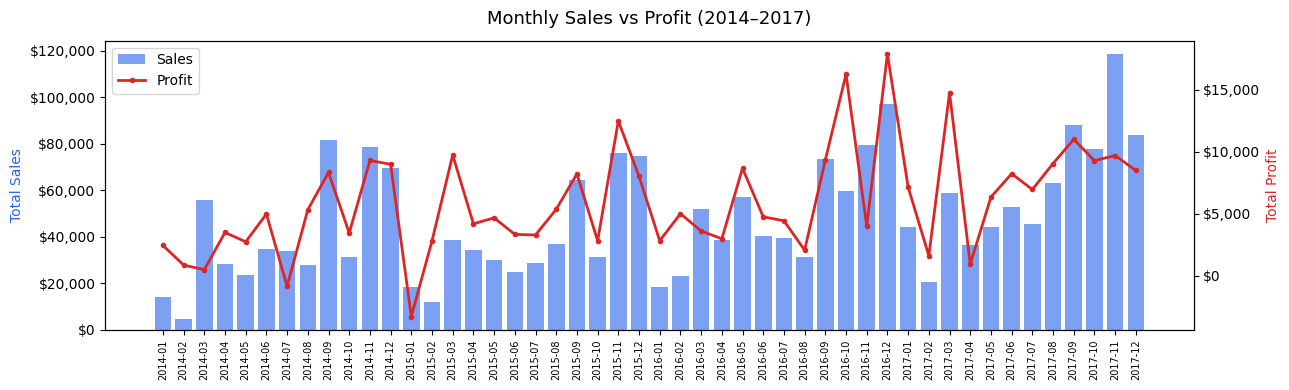

✅ monthly_sales_profit.png saved


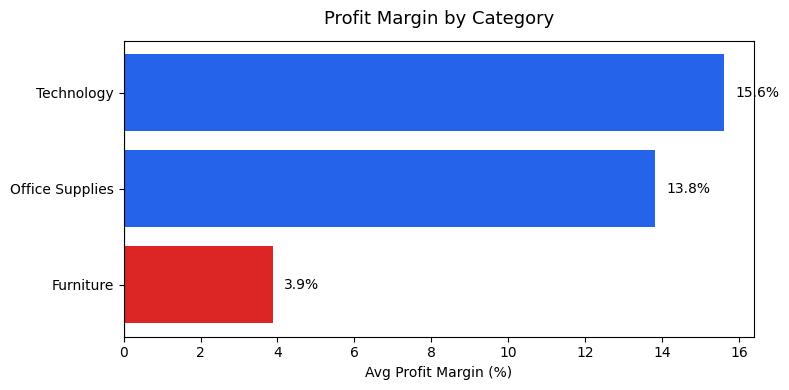

✅ margin_by_category.png saved


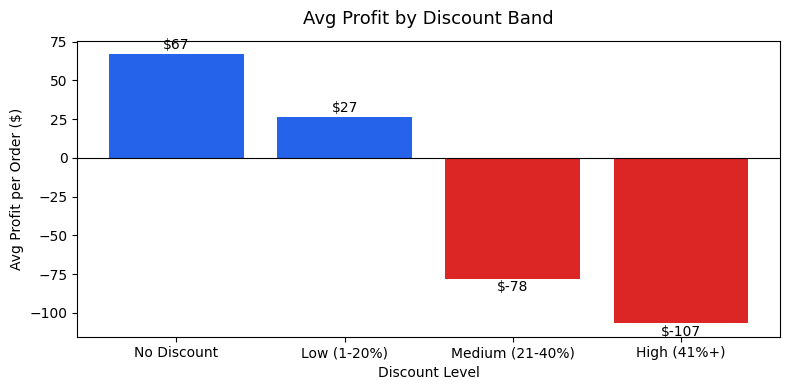

✅ discount_impact.png saved


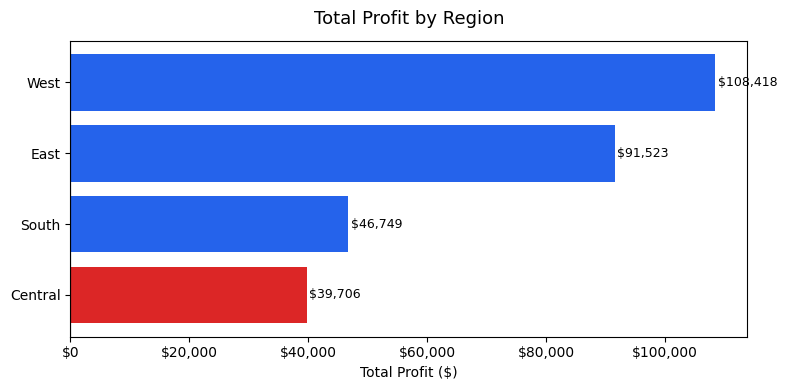

✅ profit_by_region.png saved

✅ superstore_dashboard_data.xlsx saved!
Sheet 1: 48 months
Sheet 2: 17 sub-categories
Sheet 3: 4 regions
Sheet 4: 4 discount bands


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('superstore_clean.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

# ===== 1. Monthly Profit vs Sales =====
monthly = df.groupby('Month').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index().sort_values('Month')

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
ax1.bar(monthly['Month'], monthly['Total_Sales'], color='#2563EB', alpha=0.6, label='Sales')
ax2.plot(monthly['Month'], monthly['Total_Profit'], color='#DC2626', linewidth=2, marker='o', markersize=3, label='Profit')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['Month'], rotation=90, fontsize=7)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_title('Monthly Sales vs Profit (2014–2017)', fontsize=13, pad=12)
ax1.set_ylabel('Total Sales', color='#2563EB')
ax2.set_ylabel('Total Profit', color='#DC2626')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.savefig('monthly_sales_profit.png', dpi=150)
plt.show()
print("✅ monthly_sales_profit.png saved")

# ===== 2. Profit Margin by Category =====
cat = df.groupby('Category').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Avg_Margin=('Profit Margin','mean')
).reset_index().sort_values('Avg_Margin', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#DC2626' if m < 5 else '#2563EB' for m in cat['Avg_Margin']]
bars = ax.barh(cat['Category'], cat['Avg_Margin'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, cat['Avg_Margin']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='500')
ax.set_title('Profit Margin by Category', fontsize=13, pad=12)
ax.set_xlabel('Avg Profit Margin (%)')
plt.tight_layout()
plt.savefig('margin_by_category.png', dpi=150)
plt.show()
print("✅ margin_by_category.png saved")

# ===== 3. Discount Impact =====
df['Discount Band'] = pd.cut(df['Discount'],
    bins=[-0.1, 0, 0.2, 0.4, 1.0],
    labels=['No Discount', 'Low (1-20%)', 'Medium (21-40%)', 'High (41%+)'])

disc = df.groupby('Discount Band', observed=True)['Profit'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2563EB' if v > 0 else '#DC2626' for v in disc['Profit']]
bars = ax.bar(disc['Discount Band'], disc['Profit'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, disc['Profit']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (3 if val > 0 else -8),
            f'${val:.0f}', ha='center', fontsize=10, fontweight='500')
ax.set_title('Avg Profit by Discount Band', fontsize=13, pad=12)
ax.set_ylabel('Avg Profit per Order ($)')
ax.set_xlabel('Discount Level')
plt.tight_layout()
plt.savefig('discount_impact.png', dpi=150)
plt.show()
print("✅ discount_impact.png saved")

# ===== 4. Region Performance =====
reg = df.groupby('Region').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Avg_Margin=('Profit Margin','mean')
).reset_index().sort_values('Total_Profit', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#DC2626' if m < 0 else '#2563EB' for m in reg['Avg_Margin']]
bars = ax.barh(reg['Region'], reg['Total_Profit'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, reg['Total_Profit']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Total Profit by Region', fontsize=13, pad=12)
ax.set_xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('profit_by_region.png', dpi=150)
plt.show()
print("✅ profit_by_region.png saved")

# ===== Export Excel =====
monthly_export = df.groupby('Month').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Total_Orders=('Order ID','count'),
    Avg_Margin=('Profit Margin','mean')
).reset_index().round(2)

category_export = df.groupby(['Category','Sub-Category']).agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Avg_Margin=('Profit Margin','mean'),
    Orders=('Order ID','count')
).reset_index().round(2).sort_values('Total_Profit', ascending=False)

region_export = df.groupby('Region').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Avg_Margin=('Profit Margin','mean'),
    Orders=('Order ID','count')
).reset_index().round(2).sort_values('Total_Profit', ascending=False)

discount_export = df.groupby('Discount Band', observed=True).agg(
    Avg_Profit=('Profit','mean'),
    Total_Orders=('Order ID','count'),
    Total_Loss=('Profit','sum')
).reset_index().round(2)

with pd.ExcelWriter('superstore_dashboard_data.xlsx', engine='openpyxl') as writer:
    monthly_export.to_excel(writer, sheet_name='Monthly Performance', index=False)
    category_export.to_excel(writer, sheet_name='Category Analysis', index=False)
    region_export.to_excel(writer, sheet_name='Region Performance', index=False)
    discount_export.to_excel(writer, sheet_name='Discount Impact', index=False)

print("\n✅ superstore_dashboard_data.xlsx saved!")
print(f"Sheet 1: {len(monthly_export)} months")
print(f"Sheet 2: {len(category_export)} sub-categories")
print(f"Sheet 3: {len(region_export)} regions")
print(f"Sheet 4: {len(discount_export)} discount bands")